In [1]:
from sentence_transformers import SentenceTransformer
import umap
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv("data/sample/hotel.tsv", sep="\t")
samples = df.sample(n=10_000, random_state=42)

In [3]:
models = {
    "all-mpnet-base-v2": SentenceTransformer("all-mpnet-base-v2", device="cpu"),
    "StanceSBERT": SentenceTransformer("vahidthegreat/StanceAware-SBERT", device="cpu"),
    "TourCSE": SentenceTransformer("data/sbert/export/hotel/all-mpnet-base-v2_lora_guided_sg_250", device="cpu")
}


No sentence-transformers model found with name vahidthegreat/StanceAware-SBERT. Creating a new one with mean pooling.


In [4]:
from nltk.tokenize import sent_tokenize
sentences = []
ratings = []
for r, stars in zip(samples['review'], samples['rating']):
    for s in sent_tokenize(r):
        size = len(s.split())
        if size > 3 and size < 20:
            sentences.append(s)
            ratings.append(stars)

In [5]:
sentences = sentences[:10_000]

In [6]:
embeddings_dict = {}

for name, model in models.items():
    # Encode sentences
    emb = model.encode(sentences, show_progress_bar=True)
    embeddings_dict[name] = emb


Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

Batches:   0%|          | 0/313 [00:00<?, ?it/s]

In [7]:
from sklearn.cluster import KMeans
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer

In [8]:
tm_dict = {}

for name, m in models.items():
    kmeans = KMeans(n_clusters=20)
    topic_model = BERTopic(vectorizer_model=CountVectorizer(stop_words='english'), hdbscan_model=kmeans)
    topic_model.fit_transform(sentences, embeddings=embeddings_dict[name])
        
    topic_labels = topic_model.generate_topic_labels(nr_words=5,
                                                topic_prefix=False,
                                                word_length=10,
                                                separator=", ")

    topic_model.set_topic_labels(topic_labels)
    topic_model.custom_labels_
        
    tm_dict[name] = topic_model

In [9]:
# Assuming ratings is a number from 0 to 5
full_star = "★"
empty_star = "☆"
max_stars = 5

# Generate stars string
stars_display = [full_star * int(r) + empty_star * (max_stars - int(r)) for r in ratings]

In [10]:
display_sentences = []
for s, r in zip(sentences, stars_display):
    display_sentences.append(r + ': ' + s)

In [11]:
hover_text_template = f"""
<div>
    <div style="font-size:24pt;padding:2px;">{{hover_text}}</div>
</div>
"""

In [ ]:
for name, m in models.items():
    fig = tm_dict[name].visualize_document_datamap(docs=display_sentences, embeddings=embeddings_dict[name], interactive=True, title="", enable_search=True,  custom_labels=True, int_datamap_kwds ={"font_family":"Roboto", "min_fontsize":48,"hover_text_html_template":hover_text_template,
})
    with open(f"bertopic/{name}.html", "w") as f:
        f.write(str(fig))

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


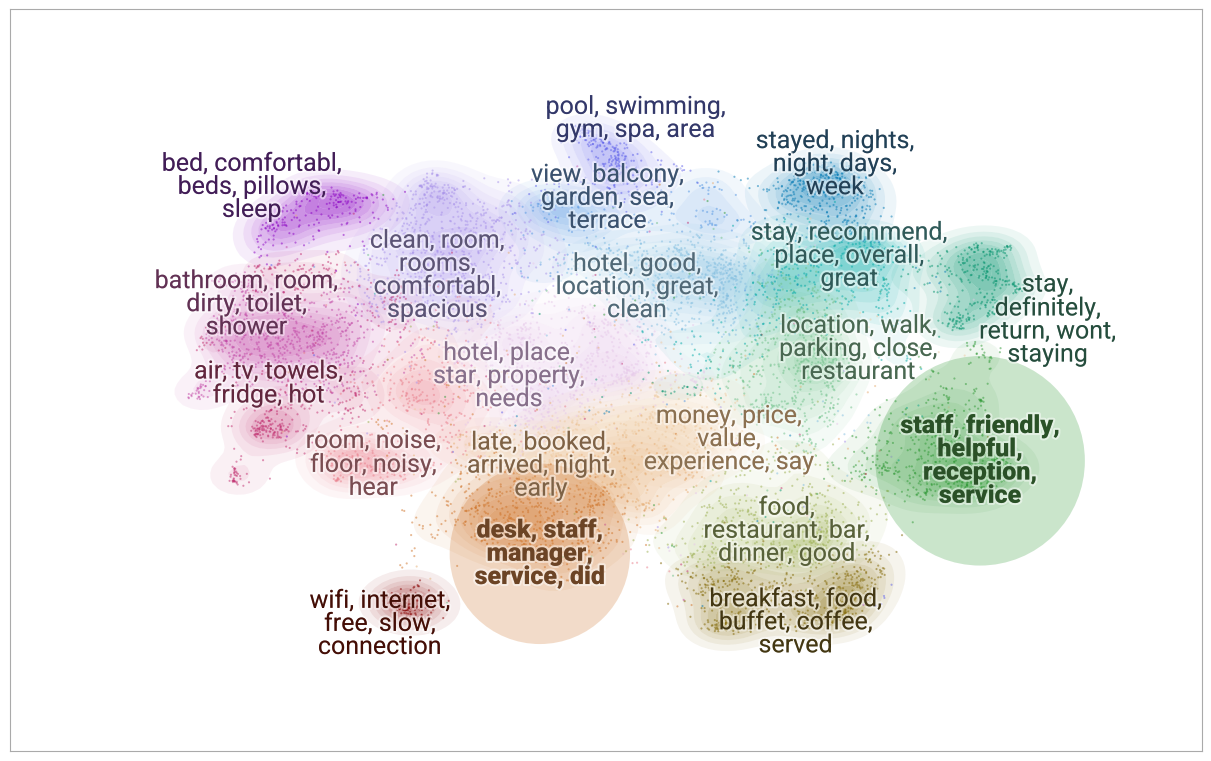

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


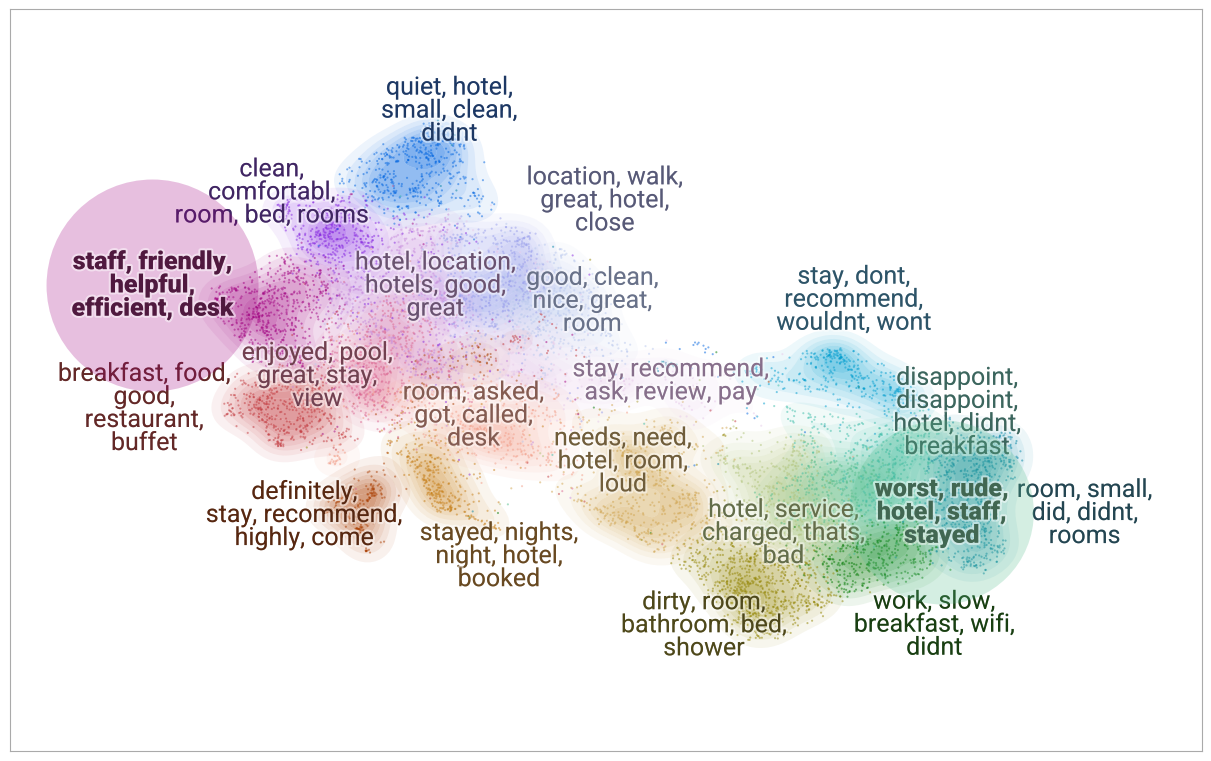

  0%|          | 0/500 [00:00<?, ?it/s]

Resetting positions to accord with alignment


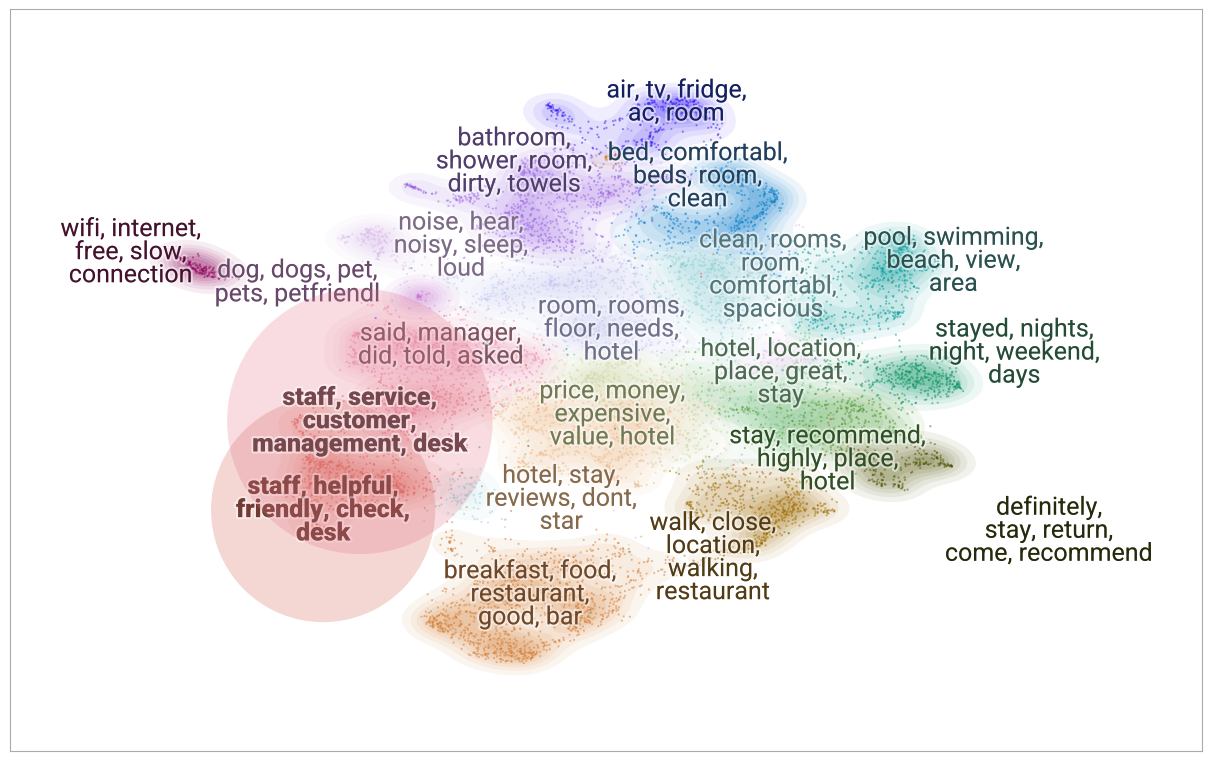

In [13]:
for name, m in models.items():
    highlights = []
    for l in tm_dict[name].custom_labels_:
        ll = l.replace(" ", "").split(",")
        if "staff" in ll:
            highlights.append(l)
        
    fig = tm_dict[name].visualize_document_datamap(docs=display_sentences, embeddings=embeddings_dict[name],  custom_labels=True, interactive=False, title="",  datamap_kwds ={"font_family":"Roboto", "label_font_size":18, 
                                                                                                                                                                               "dynamic_label_size": True,  
                                                                                                                                                                               "label_over_points":True,
                                                                                                                                                                                "highlight_labels":highlights,
    "highlight_label_keywords":{
        "fontweight":1000, "bbox":{"boxstyle":"circle", "pad":1.0, "alpha":0.25}
    },
    })
    
    fig.subplots_adjust(left=0, right=1, top=1, bottom=0)
    fig.canvas.draw()
    plt.show()